In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [2]:
PROJECT_ROOT = Path("..")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_LATENT = PROJECT_ROOT / "data" / "latent"
DATA_BACKTESTS = PROJECT_ROOT / "data" / "backtests"

returns = pd.read_parquet(DATA_PROCESSED / "returns.parquet")
sup_latent_df = pd.read_parquet(DATA_LATENT / "supervised_cnn_vae_latents.parquet")

returns.index = pd.to_datetime(returns.index)
sup_latent_df["date"] = pd.to_datetime(sup_latent_df["date"])

In [3]:
N_CLUSTERS = 6
LONG_TOP_N = 2
SHORT_BOTTOM_N = 2

REBALANCE_EVERY = 10
TRANSACTION_COST = 0.001

TRAIN_RATIO = 0.7

In [4]:
dates = np.sort(sup_latent_df["date"].unique())
split_date = dates[int(TRAIN_RATIO * len(dates))]
split_date

np.datetime64('2022-03-09T00:00:00.000000000')

In [5]:
z_cols = [c for c in sup_latent_df.columns if c.startswith("z_")]

In [6]:
train_df = sup_latent_df[sup_latent_df["date"] < split_date].copy()
test_df = sup_latent_df[sup_latent_df["date"] >= split_date].copy()

In [7]:
cluster_model = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(
        n_clusters=N_CLUSTERS,
        random_state=42,
        n_init="auto"
    ))
])

cluster_model.fit(train_df[z_cols])

train_df["cluster"] = cluster_model.predict(train_df[z_cols])
test_df["cluster"] = cluster_model.predict(test_df[z_cols])

/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: Runt

In [8]:
cluster_stats = (
    train_df
    .groupby("cluster")["target_return_10d"]
    .agg(["mean", "std", "count"])
)

cluster_stats["sharpe_like"] = cluster_stats["mean"] / cluster_stats["std"]

cluster_stats.sort_values("mean", ascending=False)

,mean,std,count,sharpe_like
cluster,,,,
5,0.036436,0.083385,1719,0.436957
4,0.021516,0.077341,1953,0.278195
1,0.019423,0.071204,4801,0.272774
3,0.015785,0.097279,3196,0.162269
2,0.010783,0.054833,14815,0.196659
0,0.005206,0.044371,22356,0.117322


In [9]:
ordered_clusters = (
    cluster_stats
    .sort_values("mean", ascending=False)
    .index
    .tolist()
)

long_clusters = ordered_clusters[:LONG_TOP_N]
short_clusters = ordered_clusters[-SHORT_BOTTOM_N:]

long_clusters, short_clusters

([5, 4], [2, 0])

In [10]:
def cluster_to_position(cluster):
    if cluster in long_clusters:
        return 1.0
    if cluster in short_clusters:
        return -1.0
    return 0.0

In [11]:
test_df["position"] = test_df["cluster"].apply(cluster_to_position)

In [12]:
score_positions = test_df.pivot(
    index="date",
    columns="ticker",
    values="position"
).sort_index().fillna(0.0)

In [13]:
def apply_rebalance_hold(positions_raw, rebalance_every):
    positions = pd.DataFrame(
        0.0,
        index=positions_raw.index,
        columns=positions_raw.columns
    )

    current_position = pd.Series(0.0, index=positions_raw.columns)

    for i, date in enumerate(positions_raw.index):
        if i % rebalance_every == 0:
            current_position = positions_raw.loc[date]

        positions.loc[date] = current_position

    return positions

In [14]:
positions = apply_rebalance_hold(
    score_positions,
    rebalance_every=REBALANCE_EVERY
)

In [15]:
def portfolio_returns_from_positions(
    positions,
    returns,
    transaction_cost=0.0
):
    next_returns = returns.shift(-1)

    common_index = positions.index.intersection(next_returns.index)
    common_cols = positions.columns.intersection(next_returns.columns)

    pos = positions.loc[common_index, common_cols]
    ret = next_returns.loc[common_index, common_cols]

    gross = (pos * ret).mean(axis=1)

    turnover = pos.diff().abs().mean(axis=1).fillna(0.0)
    net = gross - transaction_cost * turnover

    return net, turnover

In [16]:
regime_returns, regime_turnover = portfolio_returns_from_positions(
    positions,
    returns,
    transaction_cost=TRANSACTION_COST
)

regime_returns.name = "regime_policy"

In [17]:
def performance_stats(r):
    r = r.dropna()

    total_return = (1 + r).prod() - 1
    ann_return = (1 + total_return) ** (252 / len(r)) - 1
    ann_vol = r.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    equity = (1 + r).cumprod()
    drawdown = equity / equity.cummax() - 1

    return pd.Series({
        "total_return": total_return,
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": drawdown.min(),
    })

In [18]:
performance_stats(regime_returns)

total_return   -0.333027
ann_return     -0.136032
ann_vol         0.085679
sharpe         -1.587700
max_drawdown   -0.360605
dtype: float64

In [19]:
sup_backtest = pd.read_parquet(
    DATA_BACKTESTS / "supervised_vae_backtest_returns.parquet"
)

sup_backtest.index = pd.to_datetime(sup_backtest.index)

In [20]:
comparison = pd.concat(
    [
        regime_returns,
        sup_backtest["supervised_vae_direct"],
        sup_backtest["raw_feature_ridge"],
    ],
    axis=1
).dropna()

comparison.apply(performance_stats).T.sort_values("sharpe", ascending=False)

,total_return,ann_return,ann_vol,sharpe,max_drawdown
supervised_vae_direct,0.249903,0.083865,0.053503,1.567479,-0.059883
raw_feature_ridge,0.190417,0.064951,0.068585,0.947015,-0.106181
regime_policy,-0.333027,-0.136032,0.085679,-1.587700,-0.360605


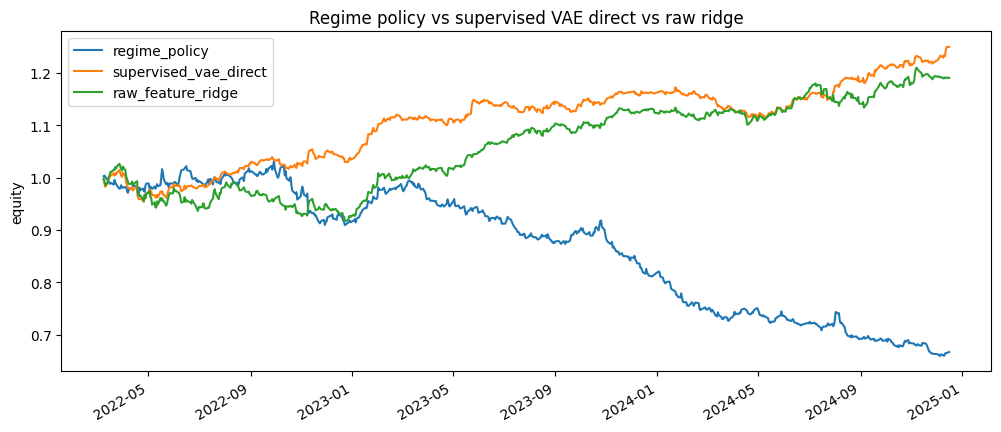

In [21]:
equity = (1 + comparison).cumprod()

equity.plot(
    figsize=(12, 5),
    title="Regime policy vs supervised VAE direct vs raw ridge"
)

plt.ylabel("equity")
plt.show()

In [23]:
comparison.to_parquet(
    DATA_BACKTESTS / "regime_policy_comparison_returns.parquet"
)

comparison.apply(performance_stats).T.to_csv(
    DATA_BACKTESTS / "regime_policy_comparison_stats.csv"
)